<a href="https://colab.research.google.com/github/teerthgangwar25/Credit-Risk-Classification-System/blob/main/Notebooks/01_EDA_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 1: EDA & Preprocessing
### Credit Risk Classification — FinTech Solutions Inc.

**Name:** _[Teerth Gangwar]_

This notebook covers Tasks 1.1–1.4 of the project: loading and exploring the German Credit dataset, exploratory data analysis, feature engineering, and preprocessing. Outputs (`X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv`) are saved for use in Notebook 2.

## Setup

Mount Google Drive and install/import required libraries.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_PATH = '/content/drive/MyDrive/T2_Project_Teerth_Gangwar'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
print(os.listdir(f'{PROJECT_PATH}/Data'))

['german_credit_data.csv']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")
%matplotlib inline

## 1.1 Load and explore

Load the dataset and get a first look: shape, data types, summary stats, missing values, and duplicates.

In [ ]:
df = pd.read_csv(f'{PROJECT_PATH}/Data/german_credit_data.csv')
print("Shape:", df.shape)
df.head()

Shape: (1000, 10)


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,56,male,1,own,little,moderate,6745,22,car,good
1,69,female,2,free,moderate,moderate,10437,70,car,good
2,46,male,3,own,quite rich,little,9763,8,car,good
3,32,female,1,own,moderate,little,18964,70,radio/TV,bad
4,60,male,2,own,moderate,little,17650,14,domestic appliances,good


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   915 non-null    object
 5   Checking account  905 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 78.3+ KB


In [ ]:
df.describe()

,Age,Job,Credit amount,Duration,Risk,Credit_to_Duration_Ratio,High_Risk_Purpose,Account_Stability
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,46.247000,1.306000,9943.912000,36.810000,0.396000,443.559034,0.268000,3.058000
std,16.288072,0.901763,5626.476201,19.334418,0.489309,578.392562,0.443139,1.214954
min,18.000000,0.000000,298.000000,4.000000,0.000000,4.197183,0.000000,0.000000
25%,33.000000,1.000000,5021.250000,21.000000,0.000000,134.455357,0.000000,2.000000
50%,46.000000,1.000000,9814.000000,36.000000,0.000000,263.827586,0.000000,3.000000
75%,60.250000,2.000000,14785.500000,53.000000,1.000000,497.363889,1.000000,4.000000
max,74.000000,3.000000,19893.000000,71.000000,1.000000,4765.500000,1.000000,6.000000


**Missing values check** — the brief flags that `Saving accounts` and `Checking account` contain missing values that need to be handled. Let's confirm and quantify.

In [ ]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
Age                  0
Sex                  0
Job                  0
Housing              0
Saving accounts     85
Checking account    95
Credit amount        0
Duration             0
Purpose              0
Risk                 0
dtype: int64

Duplicate rows: 0


## 1.2 Exploratory data analysis

Required visualizations: target distribution, numeric histograms, boxplots by risk category, and a correlation heatmap — plus two additional insightful plots of our own choosing.

**Target distribution** — checking class balance, since this affects both modeling strategy and which metrics matter later (see Notebook 3).

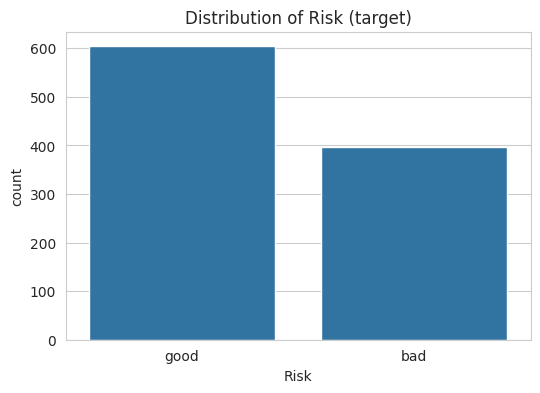

Risk
good    0.604
bad     0.396
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Risk', data=df)
plt.title('Distribution of Risk (target)')
plt.show()

print(df['Risk'].value_counts(normalize=True))

**Numeric feature distributions** — Age, Credit amount, and Duration.

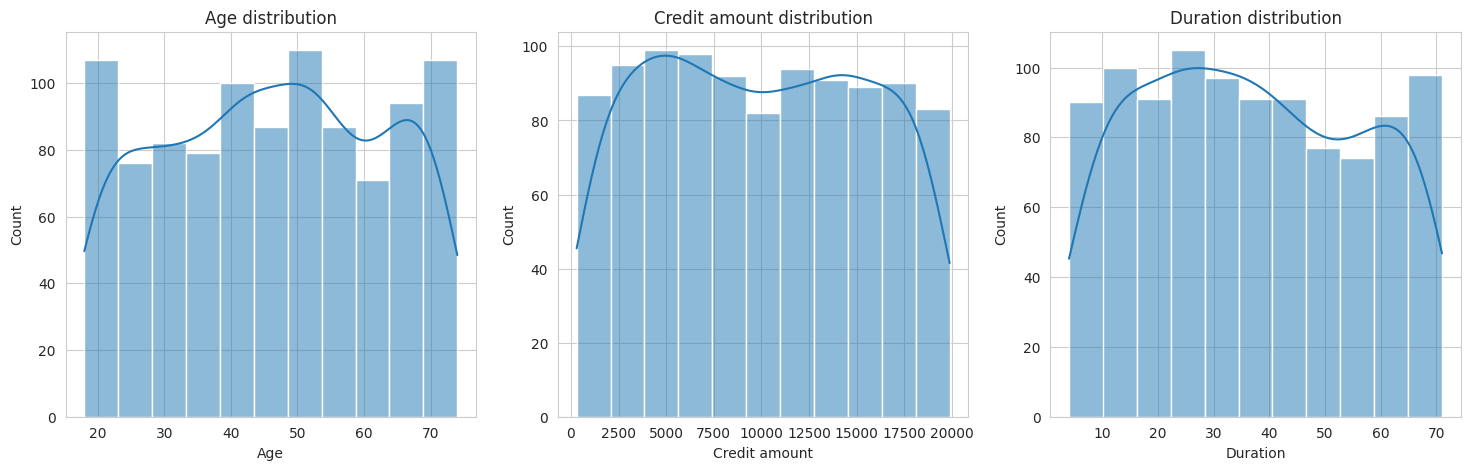

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['Age'], kde=True, ax=ax[0]).set_title('Age distribution')
sns.histplot(df['Credit amount'], kde=True, ax=ax[1]).set_title('Credit amount distribution')
sns.histplot(df['Duration'], kde=True, ax=ax[2]).set_title('Duration distribution')
plt.show()

**Boxplots by risk category** — do good vs. bad risk applicants differ visibly on these numeric features?

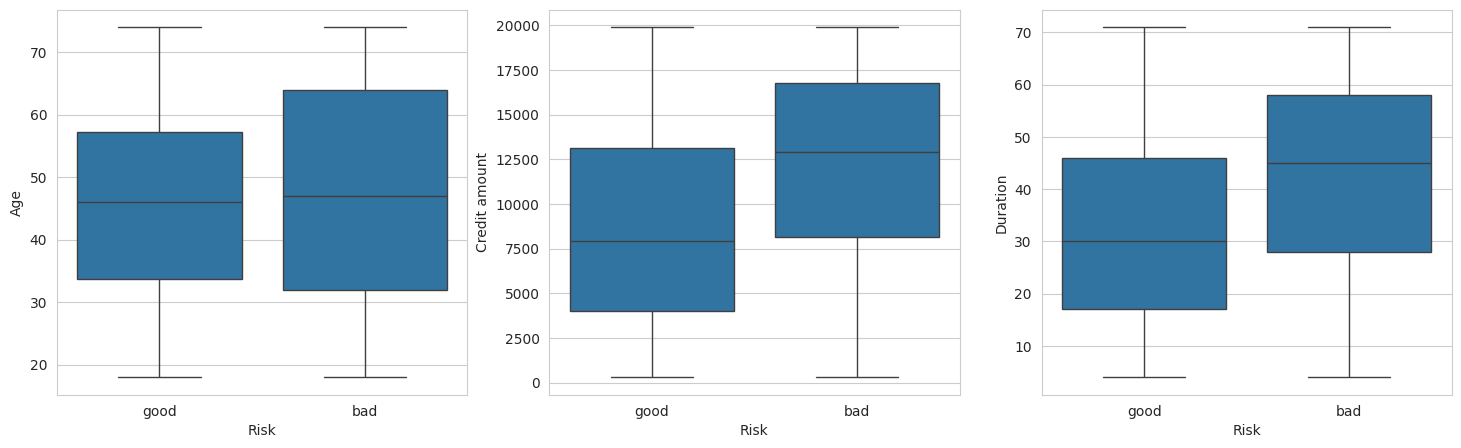

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(x='Risk', y='Age', data=df, ax=ax[0])
sns.boxplot(x='Risk', y='Credit amount', data=df, ax=ax[1])
sns.boxplot(x='Risk', y='Duration', data=df, ax=ax[2])
plt.show()

**Correlation heatmap** — numeric features only.

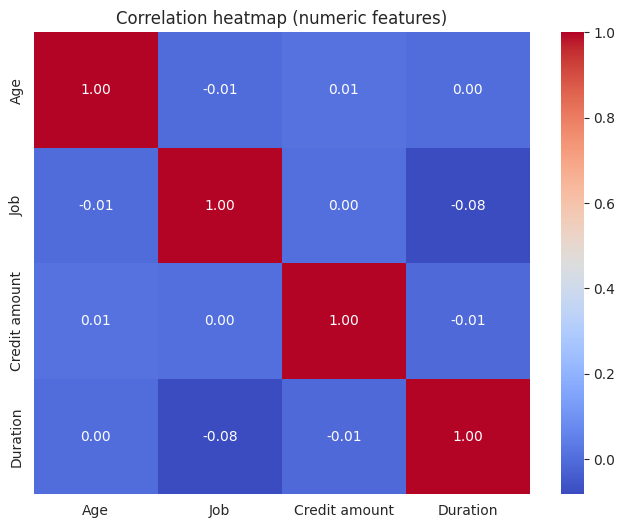

In [ ]:
plt.figure(figsize=(8, 6))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation heatmap (numeric features)')
plt.show()

**Additional plot 1 — loan purpose vs. risk.** Some purposes (e.g. education, business) may carry different default rates than others, which is relevant for the `High_Risk_Purpose` feature we engineer below.

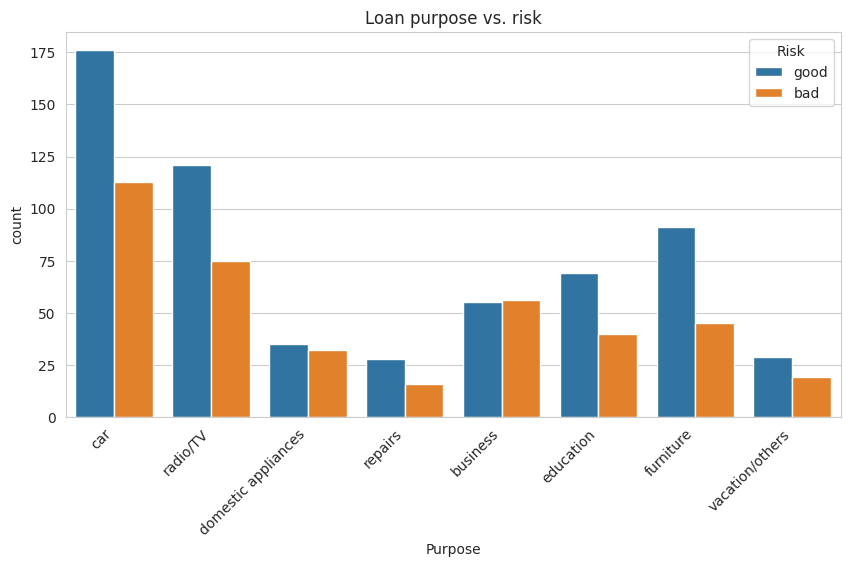

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(x='Purpose', hue='Risk', data=df)
plt.xticks(rotation=45, ha='right')
plt.title('Loan purpose vs. risk')
plt.show()

**Additional plot 2 — checking account status vs. risk.** Checking account balance is often a strong signal of financial stability.

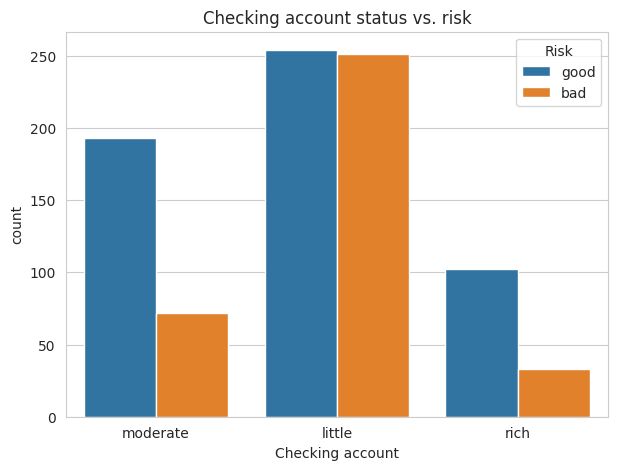

In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(x='Checking account', hue='Risk', data=df)
plt.title('Checking account status vs. risk')
plt.show()

## 1.4 Feature engineering

**Note on ordering:** we engineer features here, right after EDA and before preprocessing (1.3). This is deliberate — several of these features (e.g. `High_Risk_Purpose`, `Account_Stability`) need the *original* categorical values (`Purpose`, `Saving accounts`, `Checking account`) before those columns get one-hot encoded in 1.3. Engineering first keeps the logic readable; encoding happens once, on the final feature set.

We create four new features:

1. **`Credit_to_Duration_Ratio`** — credit amount divided by loan duration. A high ratio means a large loan repaid quickly, which changes monthly repayment burden differently than the two raw numbers do separately.
2. **`Age_Group`** — bucketed age (18–25, 26–35, 36–50, 50+). Captures non-linear age effects (e.g. very young applicants may be riskier) that a single continuous `Age` column can wash out for tree models less, but helps linear models and interpretability.
3. **`High_Risk_Purpose`** — binary flag for loan purposes we saw skew toward "bad" risk in the EDA plot above (education, business, vacation/others).
4. **`Account_Stability`** — a combined score from savings + checking account status (0 = none/missing, higher = more stable), collapsing two related columns into one interpretable signal.

In [ ]:
df['Credit_to_Duration_Ratio'] = df['Credit amount'] / df['Duration']

bins = [18, 25, 35, 50, 100]
labels = ['18-25', '26-35', '36-50', '50+']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

high_risk_purposes = ['education', 'business', 'vacation/others']
df['High_Risk_Purpose'] = df['Purpose'].isin(high_risk_purposes).astype(int)

account_score_map = {'little': 1, 'moderate': 2, 'quite rich': 3, 'rich': 3}
df['Account_Stability'] = (
    df['Saving accounts'].map(account_score_map).fillna(0) +
    df['Checking account'].map(account_score_map).fillna(0)
)

df[['Credit_to_Duration_Ratio', 'Age_Group', 'High_Risk_Purpose', 'Account_Stability']].head()

,Credit_to_Duration_Ratio,Age_Group,High_Risk_Purpose,Account_Stability
0,306.590909,50+,0,3.0
1,149.100000,50+,0,4.0
2,1220.375000,36-50,0,4.0
3,270.914286,26-35,0,3.0
4,1260.714286,50+,0,3.0


## 1.3 Data preprocessing

**Missing value strategy:** `Saving accounts` and `Checking account` have missing values. Rather than dropping rows or imputing a guessed category, we fill with `'unknown'` — because in credit data, a *missing* account status is often itself informative (e.g. no account on record can correlate with risk), not random noise. Turning it into an explicit category lets the model use that signal instead of discarding it. (Note: `Account_Stability` above already treats missing as the lowest score, for the same reason.)

**Encoding:** one-hot encode all remaining categorical columns.

**Target encoding:** `Risk` → 0 (good), 1 (bad) — so "1" corresponds to the risk we actually want to catch (ties directly to the recall requirement in the brief).

**Train-test split:** 80/20, `random_state=42`, stratified on `Risk` to preserve class balance in both sets.

**Scaling:** `StandardScaler`, fit on train only, applied to both — done *after* the split to avoid data leakage from the test set into training statistics.

In [ ]:
df['Saving accounts'] = df['Saving accounts'].fillna('unknown')
df['Checking account'] = df['Checking account'].fillna('unknown')

df['Risk'] = df['Risk'].map({'good': 0, 'bad': 1})

categorical_cols = df.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
print("Encoding:", categorical_cols)
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

df_encoded.head()

Encoding: ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose', 'Age_Group']


,Age,Job,Credit amount,Duration,Risk,Credit_to_Duration_Ratio,High_Risk_Purpose,Account_Stability,Sex_male,Housing_own,...,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others,Age_Group_26-35,Age_Group_36-50,Age_Group_50+
0,56,1,6745,22,0,306.590909,0,3.0,True,True,...,True,False,False,False,False,False,False,False,False,True
1,69,2,10437,70,0,149.100000,0,4.0,False,False,...,True,False,False,False,False,False,False,False,False,True
2,46,3,9763,8,0,1220.375000,0,4.0,True,True,...,True,False,False,False,False,False,False,False,True,False
3,32,1,18964,70,1,270.914286,0,3.0,False,True,...,False,False,False,False,True,False,False,True,False,False
4,60,2,17650,14,0,1260.714286,0,3.0,True,True,...,False,True,False,False,False,False,False,False,False,True


In [ ]:
X = df_encoded.drop('Risk', axis=1)
y = df_encoded['Risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)
print("\nTrain class balance:\n", y_train.value_counts(normalize=True))
print("\nTest class balance:\n", y_test.value_counts(normalize=True))

Train shape: (800, 27)
Test shape: (200, 27)

Train class balance:
 Risk
0    0.60375
1    0.39625
Name: proportion, dtype: float64

Test class balance:
 Risk
0    0.605
1    0.395
Name: proportion, dtype: float64


## Save outputs

Save the processed train/test splits to Drive — Notebook 2 loads these directly.

In [ ]:
X_train_scaled.to_csv(f'{PROJECT_PATH}/Data/X_train.csv', index=False)
X_test_scaled.to_csv(f'{PROJECT_PATH}/Data/X_test.csv', index=False)
y_train.to_csv(f'{PROJECT_PATH}/Data/y_train.csv', index=False)
y_test.to_csv(f'{PROJECT_PATH}/Data/y_test.csv', index=False)

print("Saved X_train, X_test, y_train, y_test to Drive.")

Saved X_train, X_test, y_train, y_test to Drive.


## Summary

- Loaded 1,000 applications, confirmed missingness in `Saving accounts` / `Checking account`, no duplicates.
- Ran 6 EDA visualizations (4 required + 2 additional) — target is imbalanced toward "good" risk, which we carry into metric choice in Notebook 3.
- Engineered 4 new features with justification for each.
- Imputed missing categoricals as `'unknown'`, one-hot encoded, stratified 80/20 split, scaled post-split to avoid leakage.
- Saved processed train/test sets for Notebook 2.